# 00 — Data foundations

Before any hypothesis is tested, this notebook establishes what is being measured, checks
that the measurement is sound, and states its limits. Everything downstream depends on it,
so it is worth reading even if the statistics chapters are what you came for.

**What this notebook answers**

1. What exactly is a "topic share" here, and why hard assignments rather than probabilities?
2. Do the numbers hold together — do shares sum to 1, does every book have metadata?
3. Which topics are solid enough to interpret, and which are dust?
4. Which topics are really one author's habit rather than a corpus-wide theme?
5. Which theory axes can actually be measured in this model, and which cannot?
6. What do the two outcome channels (star rating, rating count) look like?

Outputs go to `results/stage10_correlation_analysis/<run>/notebook_analysis/00_data_foundations/`.

In [1]:
import sys
from pathlib import Path

cwd = Path.cwd().resolve()
project_root = cwd
for _ in range(6):
    if (project_root / "configs").is_dir() and (project_root / "src").is_dir():
        break
    project_root = project_root.parent
else:
    raise RuntimeError("Could not find project root")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from src.stage10_correlation_analysis.analysis import bootstrap as boot
from src.stage10_correlation_analysis.analysis import compositional as comp
from src.stage10_correlation_analysis.analysis import effects as eff
from src.stage10_correlation_analysis.analysis import notebook_helpers as nbh

ctx = nbh.setup("00_data_foundations")
cfg = ctx.cfg
TIERS = cfg.tier_order
PALETTE = nbh.tier_palette(cfg)
TIER_COL = cfg.tier_column

Project root : /home/polina/Documents/Cursor_Projects/romantic_novels_large_corpus
Config       : configs/stage10/final_analysis.yaml
Run          : v4_l12_granular_final_call49
Model        : BERTopic call_49 — MiniLM-L12, 374 topics (348 mapped + outliers)
Outputs      : results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations


## 1. The measurement decision: hard assignments, not probabilities

BERTopic gives every sentence a probability over all 374 topics, and also a single best
topic. The earlier version of this pipeline averaged the probabilities over a book's
sentences. That turns out not to work, for a reason that has nothing to do with the model
being wrong.

A book has roughly 6,800 sentences. Averaging 374 probabilities over 6,800 sentences is
averaging a lot of noise away — and it averages away the signal too. The result was that
taxonomy category 2.1 sat at 20.23% ± 0.25 percentage points for *every book in the
corpus*. There was nothing left to compare.

Counting each sentence's single best topic instead gives a number that varies across books
and reads directly as "3.3% of this book's sentences are about X". The table below is the
measured comparison, produced by the aggregation script rather than asserted here.

The cost is small: 0.73% of sentences fall into BERTopic's outlier topic and are excluded
from the denominators, so shares are over the 373 real topics.

In [2]:
variance = nbh.load_hard_counts(cfg, "hard_vs_soft_variance")
display(variance)

ratio = (
    variance.set_index("measure").loc["hard_assignment", "median_cv"]
    / variance.set_index("measure").loc["soft_probability", "median_cv"]
)
print(
    f"\nBetween-book variation, measured as the median per-topic coefficient of variation:\n"
    f"  hard assignments carry {ratio:.1f}x more than averaged probabilities.\n"
    f"\nThe soft-probability tables are kept and re-used as a robustness check in notebook 08,\n"
    f"so this decision is tested rather than merely asserted."
)

,measure,n_topics,median_cv,mean_cv,p90_cv
0,hard_assignment,373,0.8982,1.5433,3.9556
1,soft_probability,374,0.0868,0.0901,0.1267



Between-book variation, measured as the median per-topic coefficient of variation:
  hard assignments carry 10.3x more than averaged probabilities.

The soft-probability tables are kept and re-used as a robustness check in notebook 08,
so this decision is tested rather than merely asserted.


## 2. The analysis frame

One table, one row per book, built by `06_build_analysis_frame.py`. Its columns come in
blocks, and knowing the blocks is most of what you need to read the rest of the analysis.

In [3]:
frame = nbh.load_analysis_frame(cfg)
manifest = nbh.load_book_features(cfg, "analysis_frame_manifest")

print(f"Analysis frame: {len(frame):,} books x {frame.shape[1]} columns\n")
display(manifest)

TOPIC_COLS = nbh.columns_with_prefix(frame, "topic_")
LEAF_COLS = nbh.columns_with_prefix(frame, "leaf_")
GROUP_COLS = nbh.columns_with_prefix(frame, "group_")
AXIS_COLS = [c for c in frame.columns if c.startswith("AX_") and not c.endswith(("_z", "_clr"))]

print(f"topics {len(TOPIC_COLS)} | taxonomy leaves {len(LEAF_COLS)} | "
      f"main groups {len(GROUP_COLS)} | theory axes {len(AXIS_COLS)}")

Analysis frame: 16,000 books x 591 columns



,block,prefix,n_columns
0,tier,rating_class,1
1,outcome,-,6
2,control,-,15
3,mapping_coverage,-,4
4,group_share,group_,12
5,axis,AX_,84
6,log_ratio,LR_,2
7,leaf_share_cond,leaf_,45
8,leaf_share_abs,abs_leaf_,48
9,topic_share,topic_,373


topics 373 | taxonomy leaves 45 | main groups 12 | theory axes 28


## 3. Integrity checks

These are cheap and they catch the errors that would otherwise be discovered halfway
through a hypothesis test. Each one either passes silently or raises.

In [4]:
checks = []

worst_topic = comp.check_share_sums(frame[TOPIC_COLS], name="topic shares")
checks.append(("topic shares sum to 1 per book", f"max deviation {worst_topic:.2e}", "pass"))

usable = frame[frame["analysable"]]
worst_leaf = comp.check_share_sums(usable[LEAF_COLS], name="leaf shares")
checks.append(("leaf shares sum to 1 per book", f"max deviation {worst_leaf:.2e}", "pass"))

n_unanalysable = int((~frame["analysable"]).sum())
checks.append((
    "books with interpretable text",
    f"{len(frame) - n_unanalysable:,} of {len(frame):,} ({n_unanalysable} excluded)",
    "pass" if n_unanalysable < 10 else "review",
))

tertiles = nbh.load_hard_counts(cfg, "tertile_topic_counts")
tertile_sums = tertiles.groupby(["book_id", "tertile"])["share"].sum()
checks.append((
    "tertile shares sum to 1 per tertile",
    f"max deviation {float((tertile_sums - 1).abs().max()):.2e}", "pass",
))

tier_counts = frame[TIER_COL].value_counts().reindex(TIERS)
checks.append((
    "every book has a rating tier",
    ", ".join(f"{t}={int(n):,}" for t, n in tier_counts.items()),
    "pass" if frame[TIER_COL].notna().all() else "fail",
))

missing_meta = frame[["avg_rating", "n_ratings", "author_id", "publication_year"]].isna().sum()
checks.append((
    "outcome and control coverage",
    f"missing values: {missing_meta.to_dict()}",
    "pass" if missing_meta.sum() == 0 else "review",
))

integrity = pd.DataFrame(checks, columns=["check", "result", "verdict"])
display(integrity)
ctx.save_table(integrity, "integrity_checks")

,check,result,verdict
0,topic shares sum to 1 per book,max deviation 7.55e-15,pass
1,leaf shares sum to 1 per book,max deviation 8.88e-16,pass
2,books with interpretable text,"15,999 of 16,000 (1 excluded)",pass
3,tertile shares sum to 1 per tertile,max deviation 1.11e-16,pass
4,every book has a rating tier,"low_rate=5,390, mid_rate=5,524, high_rate=5,086",pass
5,outcome and control coverage,"missing values: {'avg_rating': 0, 'n_ratings':...",pass


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/tables/integrity_checks.csv  (6 rows)


## 4. How much of the corpus can the taxonomy speak about?

Every leaf- and axis-level claim in this analysis is a claim about *mapped* text. If only a
fifth of a book's sentences fall into named taxonomy categories, then "this book is 30% X"
means 30% of that fifth, which is a much weaker statement.

This is worth checking explicitly because the previous pipeline mapped only 20% of topic
mass — the hardcoded category list it pivoted covered 15 of the 46 leaves that exist.

,mean,median,sd,min,max
mapped_mass,0.9392,0.9423,0.0220,0.0000,1.0000
axis_bearing_mass,0.3800,0.3780,0.0453,0.0000,0.6543
context_mass,0.5013,0.5014,0.0466,0.0000,1.0000
noise_leaf_mass,0.0922,0.0907,0.0174,0.0000,0.6203



On average 93.9% of a book's sentences carry a taxonomy
category. Within that, 38.0% of all sentences sit in
the narrower set of categories eligible for hypothesis axes, and 50.1%
are context (settings, objects, discourse style) that the taxonomy deliberately keeps
out of the axes.

The previous soft-probability pipeline reached mapped_mass = 0.200, so leaf-level
statements there described a fifth of the text. That is the gap this rebuild closes.


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/figures/taxonomy_coverage.png


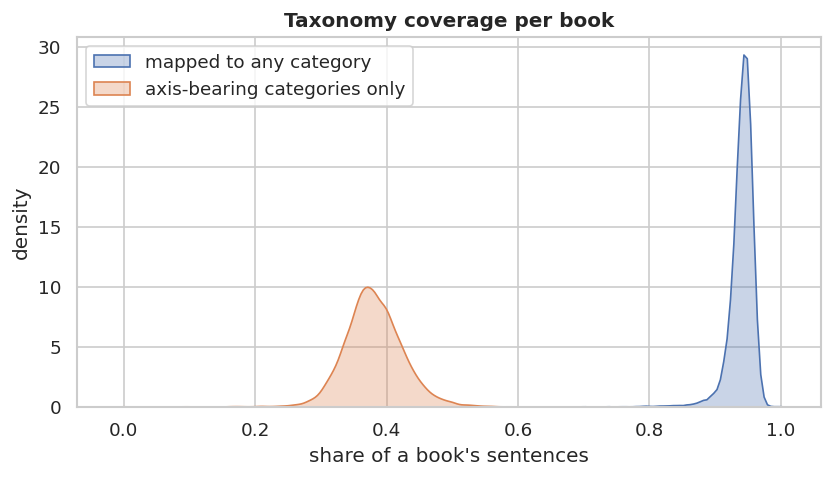

In [5]:
coverage_cols = ["mapped_mass", "axis_bearing_mass", "context_mass", "noise_leaf_mass"]
coverage_summary = frame[coverage_cols].describe().T[["mean", "50%", "std", "min", "max"]]
coverage_summary.columns = ["mean", "median", "sd", "min", "max"]
display(coverage_summary.round(4))

print(
    f"\nOn average {frame['mapped_mass'].mean():.1%} of a book's sentences carry a taxonomy\n"
    f"category. Within that, {frame['axis_bearing_mass'].mean():.1%} of all sentences sit in\n"
    f"the narrower set of categories eligible for hypothesis axes, and {frame['context_mass'].mean():.1%}\n"
    f"are context (settings, objects, discourse style) that the taxonomy deliberately keeps\n"
    f"out of the axes.\n"
    f"\nThe previous soft-probability pipeline reached mapped_mass = 0.200, so leaf-level\n"
    f"statements there described a fifth of the text. That is the gap this rebuild closes."
)

fig, ax = plt.subplots(figsize=(8, 4))
for col, label in [("mapped_mass", "mapped to any category"),
                   ("axis_bearing_mass", "axis-bearing categories only")]:
    sns.kdeplot(frame[col], ax=ax, label=label, fill=True, alpha=0.3)
ax.set_xlabel("share of a book's sentences")
ax.set_ylabel("density")
ax.set_title("Taxonomy coverage per book")
ax.legend()
ctx.save_figure(fig, "taxonomy_coverage")
plt.show()

## 5. Compositional reality

Topic shares sum to 1 within each book. That single fact constrains everything: a theme
cannot rise without another falling, so **every result in this analysis is a reallocation
of narrative attention, not an absolute amount**.

Practically this means three different scales for three different jobs:

| scale | used for | why |
|---|---|---|
| raw shares | description, plots | directly readable as "% of sentences" |
| ranks | tier comparisons | no distributional assumptions, immune to the long right tail |
| CLR (centred log-ratio) | regression | removes the sum constraint so a linear model is meaningful |

Zeros need care too. A book with N sentences cannot express a share below 1/N, so a zero
means "below 1/N" rather than "absent". Epsilon is set to half of that smallest observable
step at the median book length.

Topic shares sum to 1 within each book, so they are compositional. Every result is a relative reallocation of narrative attention, not an absolute amount: a theme rising in one book necessarily means other themes fall.

Median book length: 6,840 sentences, so the smallest observable share is
1/6,840 = 1.46e-04 and epsilon = 7.309e-05 (half of it).



CLR sanity: each row sums to 1.24e-11 (should be 0).


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/figures/compositional_scales.png


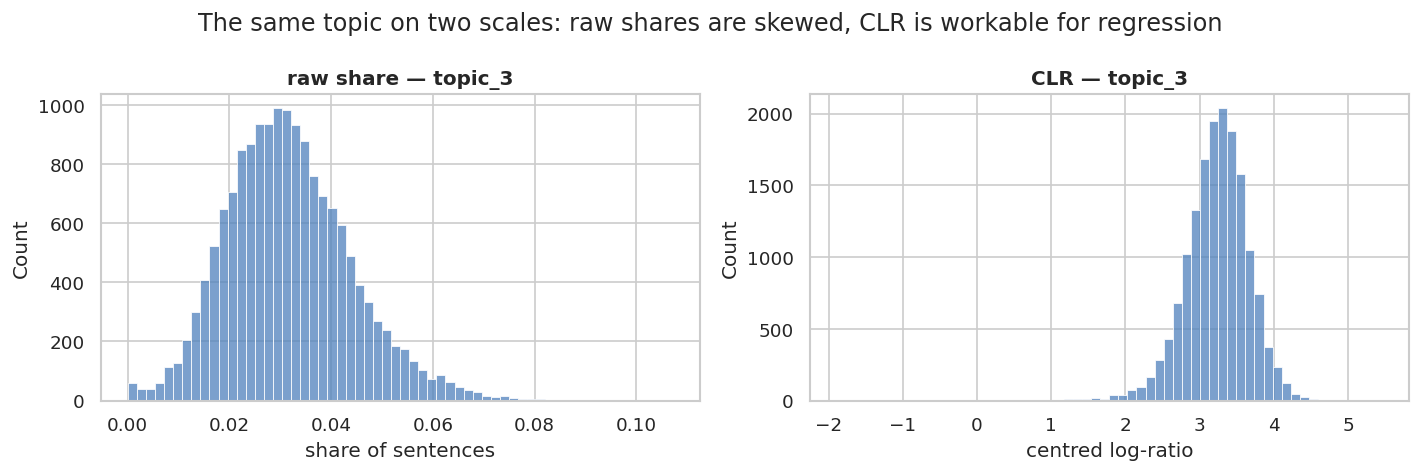

In [6]:
print(nbh.compositional_note())

book_totals = nbh.load_hard_counts(cfg, "book_totals")
epsilon = comp.epsilon_from_counts(
    book_totals["n_sentences"],
    mode=cfg.section("compositional", "epsilon_mode"),
    fallback=float(cfg.section("compositional", "epsilon_fallback")),
)
median_len = int(book_totals["n_sentences"].median())
print(
    f"\nMedian book length: {median_len:,} sentences, so the smallest observable share is\n"
    f"1/{median_len:,} = {1 / median_len:.2e} and epsilon = {epsilon:.3e} (half of it)."
)

clr_topics = comp.clr(frame[TOPIC_COLS], epsilon=epsilon)
print(f"\nCLR sanity: each row sums to {float(clr_topics.sum(axis=1).abs().max()):.2e} (should be 0).")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
example = TOPIC_COLS[frame[TOPIC_COLS].mean().to_numpy().argmax()]
sns.histplot(frame[example], bins=60, ax=axes[0], color="#4f81bd")
axes[0].set_title(f"raw share — {example}")
axes[0].set_xlabel("share of sentences")
sns.histplot(clr_topics[example], bins=60, ax=axes[1], color="#4f81bd")
axes[1].set_title(f"CLR — {example}")
axes[1].set_xlabel("centred log-ratio")
fig.suptitle("The same topic on two scales: raw shares are skewed, CLR is workable for regression")
fig.tight_layout()
ctx.save_figure(fig, "compositional_scales")
plt.show()

## 6. Topic health: which of the 373 topics are worth interpreting?

A topic that appears in 2% of books, or that averages 0.001% of sentences, cannot support a
tier comparison however large the corpus is. Three numbers separate signal from dust:

- **prevalence** — the fraction of books where the topic appears at all
- **mass** — the mean share across books
- **concentration** — how much of the topic's total mass sits in its top 1% of books; a high
  value means a few books carry it and it is not a corpus-wide theme

The health table also carries each topic's label, taxonomy category, and its Cliff's delta
between the high and low tiers, so it is the lookup table for the rest of the analysis.

In [7]:
topic_lookup = nbh.load_topic_lookup(cfg)
screen = comp.screen_columns(
    frame[TOPIC_COLS],
    min_prevalence=float(cfg.section("screening", "min_prevalence_books")),
    min_mean_share=float(cfg.section("screening", "min_mean_share")),
)

def concentration(series: pd.Series) -> float:
    """Share of a topic's total mass held by its top 1% of books."""
    ordered = series.sort_values(ascending=False)
    top = max(1, int(0.01 * len(ordered)))
    total = ordered.sum()
    return float(ordered.iloc[:top].sum() / total) if total > 0 else np.nan

health = screen.copy()
health.index.name = "feature"
health = health.reset_index()
health["topic_id"] = health["feature"].str.removeprefix("topic_").astype(int)
health["concentration_top1pct"] = [concentration(frame[c]) for c in health["feature"]]

label_cols = ["topic_id", "label", "taxonomy_main_id", "taxonomy_main_name",
              "taxonomy_main_group", "taxonomy_confidence", "taxonomy_evidence_quality",
              "taxonomy_use_in_macro_axes", "radway_phase_name"]
health = health.merge(
    topic_lookup[[c for c in label_cols if c in topic_lookup.columns]],
    on="topic_id", how="left",
)

high, low = cfg.section("tiers", "headline_contrast")
tier_effects = eff.two_group_effects(
    frame.reset_index(), TOPIC_COLS, TIER_COL, high, low,
    n_replicates=int(cfg.section("inference", "screening_ci_replicates")),
    seed=int(cfg.section("inference", "bootstrap", "seed")),
)
health = health.merge(
    tier_effects[["feature", "cliffs_delta", "ci_low", "ci_high", "ci_excludes_zero", "magnitude"]],
    on="feature", how="left",
)

print(f"Topic health across {len(health)} topics:")
print(f"  median prevalence      {health['prevalence'].median():.3f}")
print(f"  median mean share      {health['mean_share'].median():.5f}")
print(f"  median concentration   {health['concentration_top1pct'].median():.3f}")
print(f"  pass the screen        {int(health['passes_screen'].sum())} "
      f"({health['passes_screen'].mean():.1%})")
print(f"  |delta| >= {cfg.section('screening', 'effect_gates', 'cliffs_delta_small')} "
      f"between {high} and {low}: "
      f"{int((health['cliffs_delta'].abs() >= cfg.section('screening', 'effect_gates', 'cliffs_delta_small')).sum())}")

display(health.sort_values("mean_share", ascending=False).head(15)[
    ["feature", "label", "taxonomy_main_id", "prevalence", "mean_share",
     "concentration_top1pct", "cliffs_delta", "magnitude"]
])

Topic health across 373 topics:
  median prevalence      0.965
  median mean share      0.00195
  median concentration   0.056
  pass the screen        369 (98.9%)
  |delta| >= 0.11 between high_rate and low_rate: 38


,feature,label,taxonomy_main_id,prevalence,mean_share,concentration_top1pct,cliffs_delta,magnitude
0,topic_3,Demanding An Explanation,4.4,0.9982,0.0317,0.0227,-0.0118,negligible
1,topic_4,Refusing to Be Used,3.3,0.9909,0.0233,0.0402,-0.0119,negligible
2,topic_6,Whispered Reassurance,4.6,0.9951,0.0174,0.0351,0.0147,negligible
3,topic_20,Warning About Doing Things Right,9.2,0.9977,0.0152,0.0464,-0.0899,negligible
4,topic_0,Moving Through Doorways and Vehicles,8.5,0.9964,0.0130,0.0297,0.0606,negligible
5,topic_5,Flirtatious Wink Across The Room,1.7,0.9946,0.0108,0.0286,0.0050,negligible
6,topic_11,Eyes Meeting Across The Room,2.1,0.9896,0.0106,0.0335,0.0052,negligible
7,topic_144,Moving on to The Next Destination,uncertain_interpretable,0.9833,0.0095,0.0387,0.0492,negligible
8,topic_9,Coordinating Departure Times,9.2,0.9960,0.0091,0.0211,0.0469,negligible
9,topic_1,Straps Sliding Down Her Arms,2.3,0.9438,0.0090,0.0975,0.0542,negligible


Read the three panels below together, because they say something important about which
screen actually does any work.

**Prevalence screens almost nothing.** The median topic appears in 96.5% of books, and 369
of 373 topics clear the 5% prevalence gate. That is arithmetic, not a finding: a book has
about 6,800 sentences spread over 373 topics, so roughly 18 sentences land on the average
topic and "at least one sentence" is nearly guaranteed. Presence is therefore not a
discriminating variable at this granularity, and the prevalence gate is kept only to catch
a genuinely degenerate topic.

**Mass and effect size do the work.** The median topic holds 0.20% of a book's sentences,
and only 38 of 373 topics reach even a small tier difference. That ratio — 369 pass the
prevalence screen, 38 clear the effect gate — is the honest headline of this chapter, and
notebook 01 reports it as a funnel.

**Concentration is reassuring.** The median topic's top 1% of books hold only 5.6% of its
mass, so topics are spread across the corpus rather than being a handful of books' quirks.

  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/figures/topic_health_distributions.png


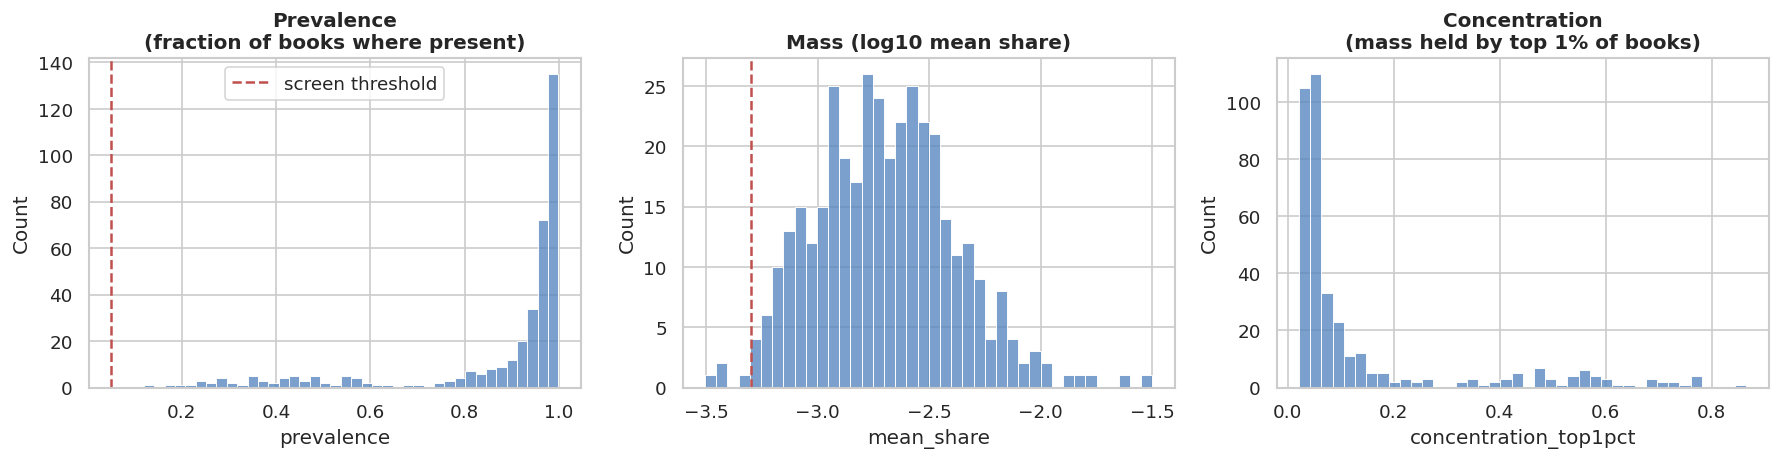

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.histplot(health["prevalence"], bins=40, ax=axes[0], color="#4f81bd")
axes[0].axvline(cfg.section("screening", "min_prevalence_books"), color="#c0504d", ls="--",
                label="screen threshold")
axes[0].set_title("Prevalence\n(fraction of books where present)")
axes[0].legend()

sns.histplot(np.log10(health["mean_share"].clip(lower=1e-8)), bins=40, ax=axes[1], color="#4f81bd")
axes[1].axvline(np.log10(float(cfg.section("screening", "min_mean_share"))), color="#c0504d", ls="--")
axes[1].set_title("Mass (log10 mean share)")

sns.histplot(health["concentration_top1pct"], bins=40, ax=axes[2], color="#4f81bd")
axes[2].set_title("Concentration\n(mass held by top 1% of books)")
fig.tight_layout()
ctx.save_figure(fig, "topic_health_distributions")
plt.show()

## 7. Authors as a shadow confounder

Romance authors imprint topics hard. Before reading "highly rated books do more X", it is
worth knowing whether topic X is really one author's recurring scene.

The corpus has 8,264 authors over 16,000 books, and 5,353 of them appear exactly once.
That distribution rules out author fixed effects — they would absorb a third of the sample
— so the strategy throughout is author-cluster-robust standard errors, a cluster bootstrap
over authors, and the dominance flags computed here.

In [9]:
author_counts = frame["author_id"].value_counts()
print(f"authors                    {frame['author_id'].nunique():,}")
print(f"authors with 2+ books      {int((author_counts >= 2).sum()):,} "
      f"covering {int(author_counts[author_counts >= 2].sum()):,} books")
print(f"single-book authors        {int((author_counts == 1).sum()):,}")
print(f"largest author             {author_counts.iloc[0]} books")
print(f"series ids                 {frame['series_id'].nunique():,}")

dominance = boot.cluster_dominance(frame, TOPIC_COLS, "author_id")
dominance = boot.flag_dominated_features(
    dominance, max_share=float(cfg.section("screening", "author_dominance_max"))
)
dominance["topic_id"] = dominance["feature"].str.removeprefix("topic_").astype(int)
dominance = dominance.merge(
    topic_lookup[["topic_id", "label"]], on="topic_id", how="left",
).merge(
    frame[["author_id", "author_name"]].drop_duplicates().rename(
        columns={"author_id": "top_cluster", "author_name": "top_author_name"}
    ).astype({"top_cluster": "string"}),
    on="top_cluster", how="left",
)

n_flagged = int(dominance["author_dominated"].sum())
print(f"\nTopics where one author holds more than "
      f"{cfg.section('screening', 'author_dominance_max'):.0%} of the mass: {n_flagged}")
display(dominance.head(15)[
    ["feature", "label", "top_author_name", "top_cluster_share", "top3_cluster_share",
     "n_clusters_present", "author_dominated"]
])

health = health.merge(
    dominance[["feature", "top_author_name", "top_cluster_share", "author_dominated"]],
    on="feature", how="left",
)
ctx.save_table(health.sort_values("cliffs_delta", key=lambda s: s.abs(), ascending=False),
               "topic_health_table")
ctx.save_table(dominance, "topic_author_dominance")

authors                    8,264
authors with 2+ books      2,911 covering 10,647 books
single-book authors        5,353
largest author             54 books
series ids                 11,160



Topics where one author holds more than 25% of the mass: 0


,feature,label,top_author_name,top_cluster_share,top3_cluster_share,n_clusters_present,author_dominated
0,topic_303,Confessing Long-Hidden Secrets,Ella Frank,0.0937,0.1560,2570,False
1,topic_362,Keeping Someone Watched and Close,Bailey Bradford,0.0829,0.1598,1517,False
2,topic_201,Admitting You Are Gay,Lynn Steward,0.0565,0.0672,7097,False
3,topic_335,Killer Targets Someone Alone,Nix Knox,0.0506,0.0851,4129,False
4,topic_175,Gentleman Offers Steadying Support,Abigail Reynolds,0.0477,0.0934,3583,False
5,topic_265,Mismatched Expectations About Seriousness,Stephani Hecht,0.0421,0.0990,3139,False
6,topic_240,Unsure How to Offer Comfort,H.M. Ward,0.0390,0.0834,3404,False
7,topic_276,Asking For A Moment,Ofelia Grand,0.0382,0.0808,3714,False
8,topic_365,Frantic Longing After Weeks Apart,Julia Alaric,0.0382,0.1068,2732,False
9,topic_278,Irritation Fading Into Distraction,Stormy Glenn,0.0374,0.0898,2969,False


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/tables/topic_health_table.csv  (373 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/tables/topic_author_dominance.csv  (373 rows)


The topics to be most careful with are the ones that are *both* author-dominated and show a
tier difference, because there the tier effect may simply be that one author is rated well.
The check below is a real one that this corpus happens to pass: the most concentrated topic
still has under 10% of its mass in its top author, comfortably below the 25% flag. Author
effects therefore have to be handled through clustered standard errors and the cluster
bootstrap rather than by excluding individual topics.

In [10]:
gate = float(cfg.section("screening", "effect_gates", "cliffs_delta_small"))
suspect = health[
    health["author_dominated"].fillna(False)
    & (health["cliffs_delta"].abs() >= gate)
].sort_values("cliffs_delta", key=lambda s: s.abs(), ascending=False)

print(f"{len(suspect)} topics are both author-dominated and show |Cliff's delta| >= {gate}.")
print("These are treated as author signatures rather than tier signals in later chapters.")
display(suspect[["feature", "label", "top_author_name", "top_cluster_share",
                 "cliffs_delta", "magnitude"]].head(20))
ctx.save_table(suspect, "author_signature_topics")

0 topics are both author-dominated and show |Cliff's delta| >= 0.11.
These are treated as author signatures rather than tier signals in later chapters.


,feature,label,top_author_name,top_cluster_share,cliffs_delta,magnitude


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/tables/author_signature_topics.csv  (0 rows)


## 8. Axis coverage audit: which hypotheses are measurable at all?

This is the table that would have prevented the previous run's quietest failure. Four axes
were emitted as exactly `0.0` for all 16,000 books, because their taxonomy components had
no topics — and a column of zeros looks like a real variable in a regression table.

The rebuild refuses to emit an axis whose components are empty, and records per component
how many topics and how much corpus mass it rests on.

In [11]:
axis_coverage = nbh.load_book_features(cfg, "axis_coverage")
axis_summary = nbh.load_book_features(cfg, "axis_coverage_summary")
axis_definitions = nbh.load_book_features(cfg, "axis_definitions")

print("Axis verdicts (an axis is as weak as its weakest signed leg):")
display(axis_summary["axis_verdict"].value_counts().to_frame("n_axes"))

confirmatory = axis_summary[axis_summary["hypothesis_role"] == "confirmatory"]
display(confirmatory[["axis", "hypothesis", "axis_verdict", "n_components",
                      "n_viable", "n_weak", "n_empty", "empty_leaves"]])

Axis verdicts (an axis is as weak as its weakest signed leg):


,n_axes
axis_verdict,
weak,13
viable,10


,axis,hypothesis,axis_verdict,n_components,n_viable,n_weak,n_empty,empty_leaves
0,AX_explicitness,H1,viable,1,1,0,0,
1,AX_miscommunication,H6,viable,1,1,0,0,
2,AX_protective_care,H4,viable,1,1,0,0,
3,AX_dark_vs_tender,H5,weak,7,6,0,1,3.1
4,AX_hea_index,H2,weak,3,1,2,0,
5,AX_love_over_sex,H1,weak,3,2,0,1,3.1
6,AX_luxury_composite,H3,weak,5,1,2,2,"6.1a, 6.7"
7,AX_material_social_display,H3,weak,4,2,2,0,
8,AX_payoff_safety,"H2,H3",weak,2,1,0,1,3.1
9,AX_possessiveness,H4,weak,1,0,1,0,


In [12]:
empty_components = axis_coverage[axis_coverage["verdict"] == "empty"]
print("Taxonomy categories with no topics in this model, and the axes that wanted them:\n")
display(
    empty_components.groupby("leaf_id")["axis"].apply(lambda s: ", ".join(sorted(set(s))))
    .to_frame("axes_affected")
)

weak_components = axis_coverage[axis_coverage["verdict"] == "weak"]
print("\nAnd the categories that exist but rest on one or two topics — real, but too thin to")
print("carry an axis on their own:\n")
display(
    weak_components.groupby("leaf_id")
    .agg(n_topics=("n_topics", "max"), axes_affected=("axis", lambda s: ", ".join(sorted(set(s)))))
)

print(
    "\nThese are substantive findings about the corpus rather than bugs:\n"
    "  6.1a elite romantic status and 6.7 aristocracy are empty, and 6.6 material glamour\n"
    "  holds a single topic. This is a multi-genre popular-romance corpus (contemporary,\n"
    "  paranormal, historical, YA, mystery), not a billionaire-lifestyle collection: across\n"
    "  all 348 mapped topics there is essentially no luxury vocabulary. H3 as originally\n"
    "  written is therefore not measurable, and is reframed as AX_material_social_display,\n"
    "  built only from leaves that carry topics.\n"
    "  2.4 post-sex aftercare is empty upstream at Stage08, so aftercare cannot be separated\n"
    "  from explicit sex (2.3).\n"
    "  3.1 positive resolution is empty by taxonomy design: v2.4 routes relief into 4.5 and\n"
    "  reassurance into 4.6. The payoff guard below handles the consequence.\n"
    "  5.3a wedding planning and 8.3a ring exchange hold one topic each, so the HEA axis is\n"
    "  effectively leaf 4.5 with decoration — stated here, and tested that way in notebook 05."
)

Taxonomy categories with no topics in this model, and the axes that wanted them:



,axes_affected
leaf_id,
2.4,AX_sexual_tension_explicit_intimacy
3.1,"AX_dark_vs_tender, AX_love_over_sex, AX_miscom..."
6.1a,"AX_luxury_composite, AX_status_power"
6.7,"AX_luxury_composite, AX_status_power"



And the categories that exist but rest on one or two topics — real, but too thin to
carry an axis on their own:



,n_topics,axes_affected
leaf_id,,
4.7,2,"AX_coercion_risk_watchlist, AX_possessiveness,..."
5.3a,1,"AX_hea_index, AX_luxury_composite, AX_material..."
6.4,1,AX_economic_dependency
6.6,1,"AX_luxury_composite, AX_status_power"
7.4,2,AX_coercion_risk_watchlist
8.3a,1,"AX_hea_index, AX_material_social_display"



These are substantive findings about the corpus rather than bugs:
  6.1a elite romantic status and 6.7 aristocracy are empty, and 6.6 material glamour
  holds a single topic. This is a multi-genre popular-romance corpus (contemporary,
  paranormal, historical, YA, mystery), not a billionaire-lifestyle collection: across
  all 348 mapped topics there is essentially no luxury vocabulary. H3 as originally
  written is therefore not measurable, and is reframed as AX_material_social_display,
  built only from leaves that carry topics.
  2.4 post-sex aftercare is empty upstream at Stage08, so aftercare cannot be separated
  from explicit sex (2.3).
  3.1 positive resolution is empty by taxonomy design: v2.4 routes relief into 4.5 and
  reassurance into 4.6. The payoff guard below handles the consequence.
  5.3a wedding planning and 8.3a ring exchange hold one topic each, so the HEA axis is
  effectively leaf 4.5 with decoration — stated here, and tested that way in notebook 05.


In [13]:
guard = nbh.load_book_features(cfg, "payoff_guard_verdict")
display(guard)
if bool(guard.loc[0, "fallback_active"]):
    print(
        f"Guard active. AX_payoff_safety was defined as 4.5 + 3.1, and 3.1 has "
        f"{int(guard.loc[0, 'n_topics'])} topics, so the axis rests on 4.5 alone.\n"
        f"Two things follow, both visible in the frame rather than hidden:\n"
        f"  AX_payoff_safety_fallback = {guard.loc[0, 'fallback_leaves']} is provided as the\n"
        f"  broader alternative;\n"
        f"  AX_protective_care_resid is 4.6 residualised on {guard.loc[0, 'residualise_h4_on']},\n"
        f"  because 4.6 feeds both the payoff fallback and H4's positive leg. H4 uses the\n"
        f"  residualised form so the shared component is stated once, not counted twice."
    )

print("\nHow every axis is actually defined:")
display(axis_definitions)
ctx.save_table(axis_summary, "axis_coverage_summary")
ctx.save_table(axis_definitions, "axis_definitions")

,trigger_leaf,n_topics,min_topics,fallback_active,fallback_leaves,residualise_h4_on
0,3.1,0,3,True,"4.5, 4.6",4.5


Guard active. AX_payoff_safety was defined as 4.5 + 3.1, and 3.1 has 0 topics, so the axis rests on 4.5 alone.
Two things follow, both visible in the frame rather than hidden:
  AX_payoff_safety_fallback = 4.5, 4.6 is provided as the
  broader alternative;
  AX_protective_care_resid is 4.6 residualised on 4.5,
  because 4.6 feeds both the payoff fallback and H4's positive leg. H4 uses the
  residualised form so the shared component is stated once, not counted twice.

How every axis is actually defined:


,axis,method,definition,hypothesis,role
0,AX_dark_vs_tender,difference,+1*3.2 +1*4.4 +1*7.2 +1*7.3 -1*3.1 -1*2.2 -1*4.6,H5,confirmatory
1,AX_explicitness,weighted_sum,+1*2.3,H1,confirmatory
2,AX_hea_index,weighted_sum,+1*4.5 +0.8*5.3a +0.5*8.3a,H2,confirmatory
3,AX_love_over_sex,difference,+1*4.5 +1*3.1 -1*2.3,H1,confirmatory
4,AX_luxury_composite,weighted_sum_from_composite,+1*6.6 +1*6.7 +0.7*6.1a +0.3*5.3a +0.3*8.2,H3,confirmatory
5,AX_luxury_x_love,product,AX_luxury_composite x AX_payoff_safety,H3,confirmatory
6,AX_material_display_x_payoff,product,AX_material_social_display x AX_payoff_safety,H3,confirmatory
7,AX_material_social_display,weighted_sum,+1*1.6 +1*8.2 +0.5*5.3a +0.5*8.3a,H3,confirmatory
8,AX_miscommunication,weighted_sum,+1*4.3,H6,confirmatory
9,AX_payoff_safety,weighted_sum,+1*4.5 +1*3.1,"H2,H3",confirmatory


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/tables/axis_coverage_summary.csv  (23 rows)
  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/tables/axis_definitions.csv  (26 rows)


## 9. The two outcome channels

Goodreads gives two signals, and they measure different things:

- **quality** — the average star rating, i.e. how much readers who read it liked it
- **reach** — how many people rated it at all, i.e. how far the book travelled

They correlate at r ≈ 0.12 in this corpus, which is the empirical reason they are analysed
separately rather than combined into one "success" variable. A theme can raise one and
lower the other, and collapsing them would hide exactly that.

The quality channel also needs a correction. A book with 3 ratings averaging 4.9 is not
better than one with 3,000 averaging 4.3, but a raw mean says it is. The shrunk rating pulls
thin books toward the corpus mean in proportion to how little evidence they have.

In [14]:
r_quality_reach = float(frame["avg_rating"].corr(frame["log_n_ratings"]))
print(f"Correlation between quality and reach: r = {r_quality_reach:.3f}\n")

outcome_summary = frame[["avg_rating", "rating_shrunk", "n_ratings", "log_n_ratings",
                         "reliability"]].describe().T
display(outcome_summary.round(3))

thin = int((frame["n_ratings"] < cfg.section("outcomes", "quality", "sensitivity_min_ratings")).sum())
print(
    f"\n{thin:,} books ({thin / len(frame):.1%}) have fewer than "
    f"{cfg.section('outcomes', 'quality', 'sensitivity_min_ratings')} ratings. Their star\n"
    f"averages are noisy, which is why the quality channel is fit weighted by reliability\n"
    f"v/(v+m), with unweighted and n>=30 fits reported as sensitivity checks."
)

Correlation between quality and reach: r = 0.124



,count,mean,std,min,25%,50%,75%,max
avg_rating,"16,000.0000",3.9100,0.3370,1.2700,3.7100,3.9300,4.1400,5.0000
rating_shrunk,"16,000.0000",3.9220,0.1550,2.8500,3.8420,3.9140,3.9950,4.6310
n_ratings,"16,000.0000","3,023.6000","16,923.5590",1.0000,63.0000,263.0000,948.0000,"737,888.0000"
log_n_ratings,"16,000.0000",5.6500,2.0540,0.6930,4.1590,5.5760,6.8550,13.5120
reliability,"16,000.0000",0.4900,0.3200,0.0040,0.1930,0.5000,0.7830,1.0000



1,909 books (11.9%) have fewer than 30 ratings. Their star
averages are noisy, which is why the quality channel is fit weighted by reliability
v/(v+m), with unweighted and n>=30 fits reported as sensitivity checks.


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/figures/outcome_channels.png


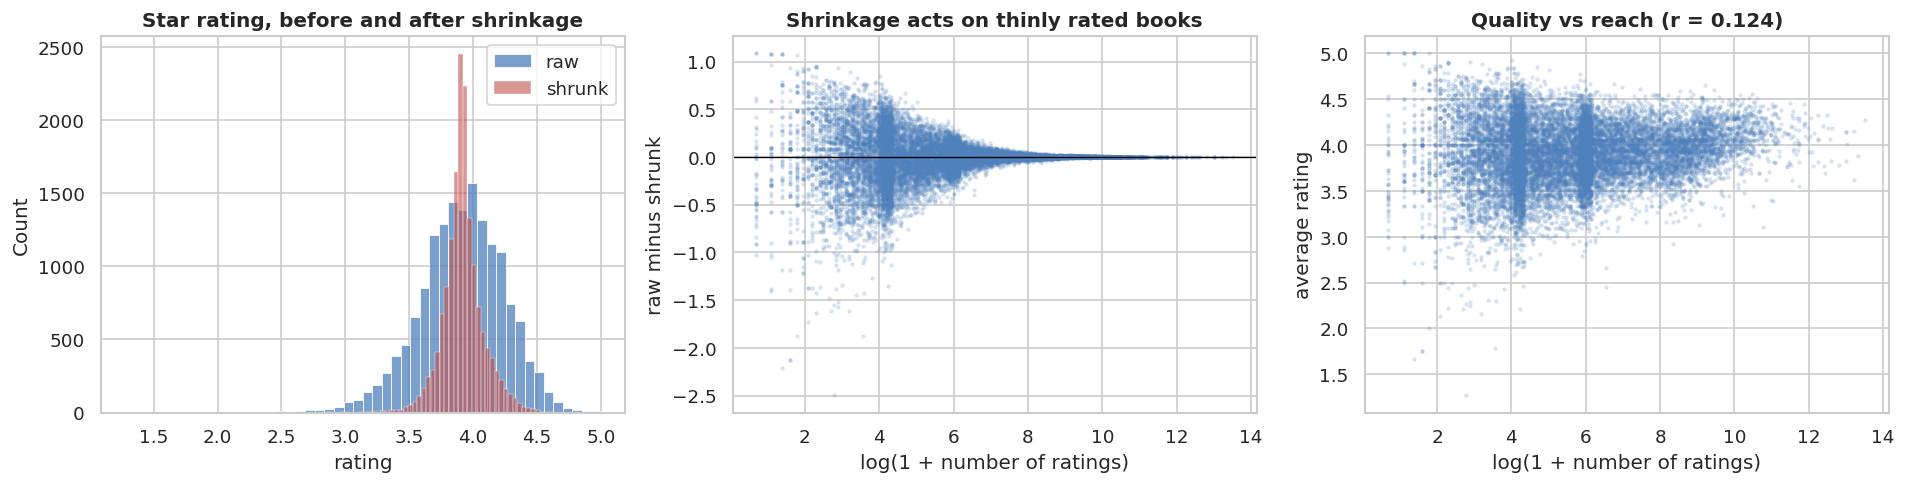

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

sns.histplot(frame["avg_rating"], bins=50, ax=axes[0], color="#4f81bd", label="raw")
sns.histplot(frame["rating_shrunk"], bins=50, ax=axes[0], color="#c0504d", alpha=0.6, label="shrunk")
axes[0].set_title("Star rating, before and after shrinkage")
axes[0].set_xlabel("rating")
axes[0].legend()

axes[1].scatter(frame["log_n_ratings"], frame["avg_rating"] - frame["rating_shrunk"],
                s=3, alpha=0.15, color="#4f81bd")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_xlabel("log(1 + number of ratings)")
axes[1].set_ylabel("raw minus shrunk")
axes[1].set_title("Shrinkage acts on thinly rated books")

axes[2].scatter(frame["log_n_ratings"], frame["avg_rating"], s=3, alpha=0.15, color="#4f81bd")
axes[2].set_xlabel("log(1 + number of ratings)")
axes[2].set_ylabel("average rating")
axes[2].set_title(f"Quality vs reach (r = {r_quality_reach:.3f})")

fig.tight_layout()
ctx.save_figure(fig, "outcome_channels")
plt.show()

## 10. The tiers

Tier comparisons throughout use `rating_class`, a three-way split of the corpus by average
rating. With about 5,000 books per tier, statistical significance is nearly automatic:
differences far too small to matter still clear p < 0.05. Interpretation is therefore gated
on effect size and its bootstrap confidence interval, and the p-value is reported as a
footnote.

,n_books,mean_rating,min_rating,max_rating,median_n_ratings,mean_pages,mean_year,mean_sentences
rating_class,,,,,,,,
low_rate,5390,3.5500,1.2700,3.7800,146.0000,237.3700,"2,011.7700","6,220.4500"
mid_rate,5524,3.9300,3.7800,4.0700,397.5000,271.5800,"2,012.5600","7,341.2000"
high_rate,5086,4.2700,4.0800,5.0000,244.0000,289.3200,"2,013.4900","8,026.5900"


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/tables/tier_profile.csv  (3 rows)

With about 5,086 books per tier, a p-value below 0.05 is nearly automatic: differences far too small to matter still clear the threshold. Read the effect size and its confidence interval, and treat the p-value as a footnote.


  saved figure: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/figures/tier_definition.png


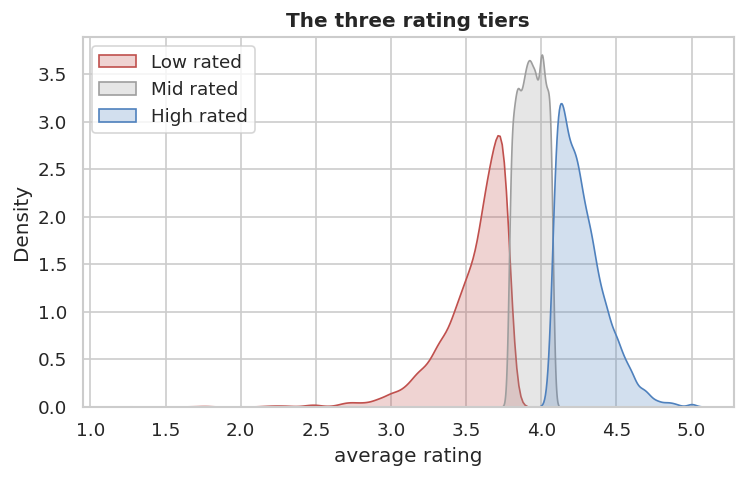

In [16]:
tier_profile = frame.groupby(TIER_COL, observed=True).agg(
    n_books=("avg_rating", "size"),
    mean_rating=("avg_rating", "mean"),
    min_rating=("avg_rating", "min"),
    max_rating=("avg_rating", "max"),
    median_n_ratings=("n_ratings", "median"),
    mean_pages=("num_pages", "mean"),
    mean_year=("publication_year", "mean"),
    mean_sentences=("n_sentences", "mean"),
).reindex(TIERS)
display(tier_profile.round(2))
ctx.save_table(tier_profile.reset_index(), "tier_profile")

print("\n" + nbh.significance_note(int(tier_profile["n_books"].min())))

fig, ax = plt.subplots(figsize=(7, 4))
for tier in TIERS:
    sns.kdeplot(frame.loc[frame[TIER_COL] == tier, "avg_rating"],
                ax=ax, label=cfg.section("tiers", "labels")[tier],
                color=PALETTE[tier], fill=True, alpha=0.25)
ax.set_xlabel("average rating")
ax.set_title("The three rating tiers")
ax.legend()
ctx.save_figure(fig, "tier_definition")
plt.show()

## 11. Foundations summary

What the rest of the analysis rests on, and what it cannot do.

In [17]:
foundations = pd.DataFrame([
    ("measure", "hard topic assignment: share of a book's sentences whose best topic is t"),
    ("why", f"{ratio:.1f}x more between-book variation than averaged probabilities"),
    ("books", f"{len(frame):,} ({n_unanalysable} excluded for having no interpretable text)"),
    ("topics", f"{len(TOPIC_COLS)} real topics; outlier topic excluded from denominators"),
    ("taxonomy leaves", f"{len(LEAF_COLS)} present, covering {frame['mapped_mass'].mean():.1%} of sentences"),
    ("theory axes", f"{len(AXIS_COLS)} built; "
                    f"{int((axis_summary['axis_verdict'] == 'viable').sum())} viable, "
                    f"{int((axis_summary['axis_verdict'] == 'weak').sum())} weak"),
    ("outcomes", f"quality (star rating, shrunk) and reach (log ratings), r = {r_quality_reach:.3f}"),
    ("clustering", f"{frame['author_id'].nunique():,} authors, "
                   f"{int((author_counts == 1).sum()):,} with one book"),
    ("author-flagged topics", f"{n_flagged} topics where one author holds >"
                              f"{cfg.section('screening', 'author_dominance_max'):.0%} of the mass"),
    ("not measurable", "H3 as luxury (6.1a/6.6/6.7 empty); aftercare separate from sex (2.4 empty)"),
    ("interpretation limit", "all effects are relative reallocations of attention, not absolute amounts"),
], columns=["item", "value"])
display(foundations)
ctx.save_table(foundations, "foundations_summary")

print("\nNext: 01_topic_landscape.ipynb — what differs across tiers at the finest granularity.")

,item,value
0,measure,hard topic assignment: share of a book's sente...
1,why,10.3x more between-book variation than average...
2,books,"16,000 (1 excluded for having no interpretable..."
3,topics,373 real topics; outlier topic excluded from d...
4,taxonomy leaves,"45 present, covering 93.9% of sentences"
5,theory axes,"28 built; 10 viable, 13 weak"
6,outcomes,"quality (star rating, shrunk) and reach (log r..."
7,clustering,"8,264 authors, 5,353 with one book"
8,author-flagged topics,0 topics where one author holds >25% of the mass
9,not measurable,H3 as luxury (6.1a/6.6/6.7 empty); aftercare s...


  saved table: results/stage10_correlation_analysis/v4_l12_granular_final_call49/notebook_analysis/00_data_foundations/tables/foundations_summary.csv  (11 rows)

Next: 01_topic_landscape.ipynb — what differs across tiers at the finest granularity.
